In [ ]:
import tensorflow.keras.backend as K
from tensorflow.keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from hyperopt.pyll.base import scope
from sklearn.model_selection import KFold

from tensorflow.keras.optimizers import Adam,Nadam,Adamax
from time import perf_counter


import tinyDA as tda
from scipy.stats import multivariate_normal, uniform
import arviz as az



In [1]:
import numpy as np
from matplotlib import pyplot as plt

import tensorflow as tf
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="tensorflow")

import keras
import sys
import os
import logging

# Set TensorFlow logging level to ERROR
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
# Configure Python logging to suppress detailed Keras messages
logging.getLogger('tensorflow').setLevel(logging.ERROR)


sys.path.append('../utils')
from Structure import *
from pathlib import Path
from module_utils import * 
from data_collection import *
# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)


True

In [2]:
# introduction of a seed for reproducibility purposes
seed = 10
tf.random.set_seed(seed)
np.random.seed(seed)
keras.utils.set_random_seed(seed)

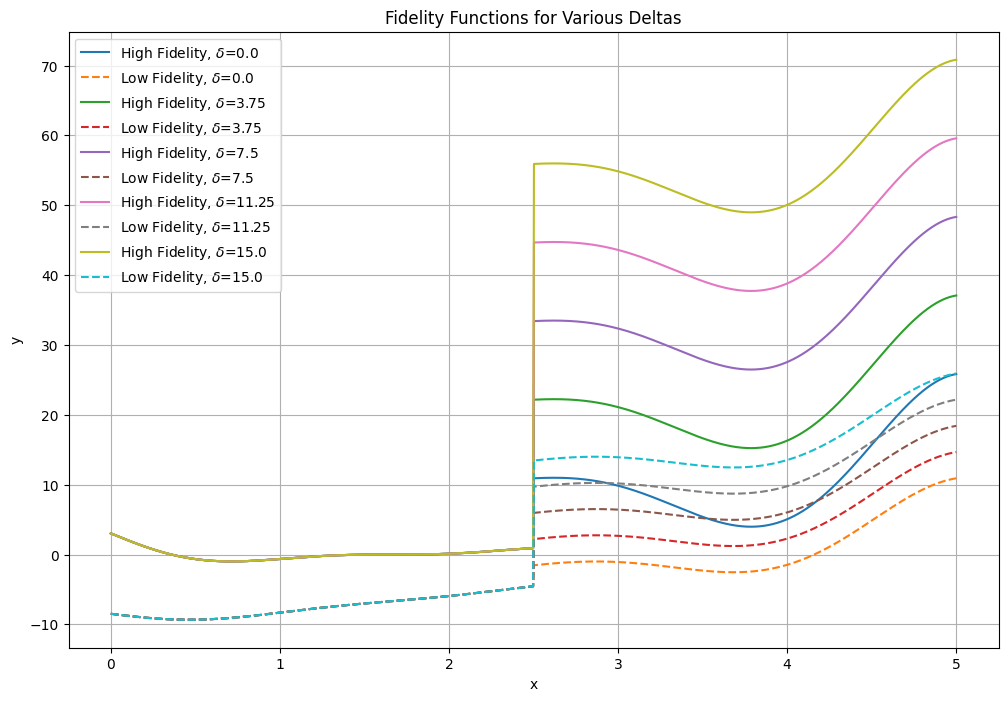

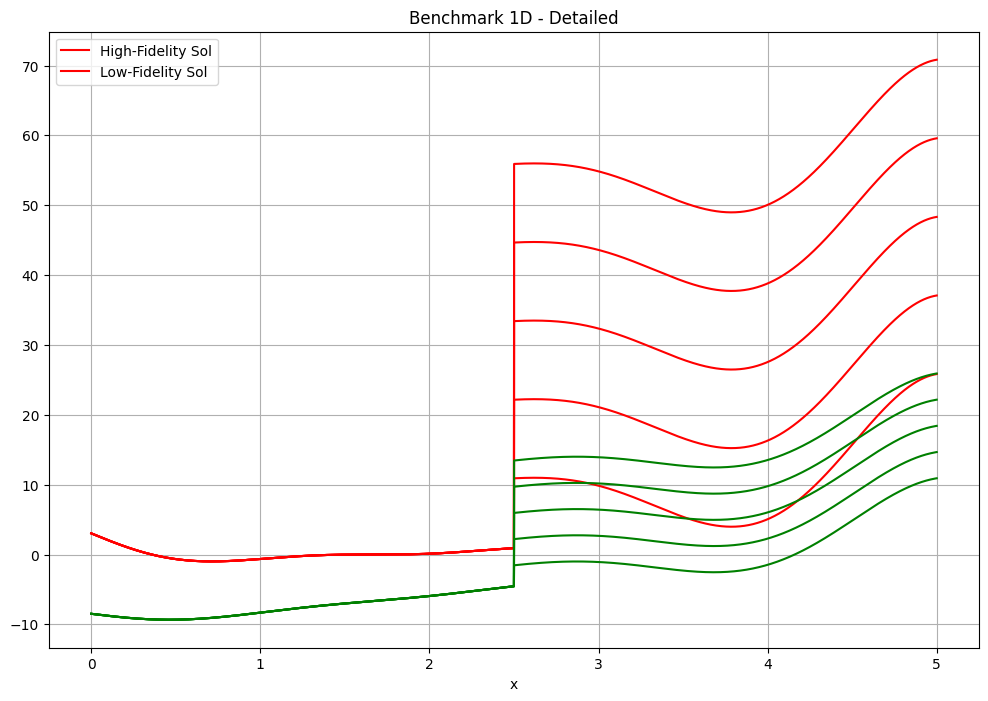

In [3]:
example = "Discontinuous"
fidelity_func = FidelityFunctionModified(example)
fidelity_func.plot_functions()
fidelity_func.plot_detailed_functions()

In [4]:
data=fidelity_func.get_parameters(example)

The function training took 37.367426 seconds.


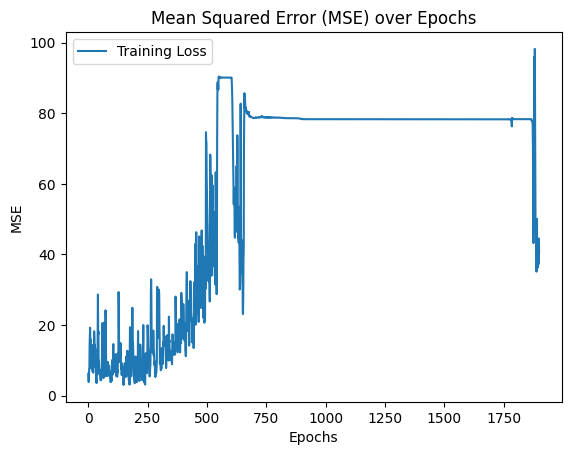

Test MSE: 577.8508038383619
R^2: -0.3648429260334054


Text(0.5, 1.0, 'Low fidelity model')

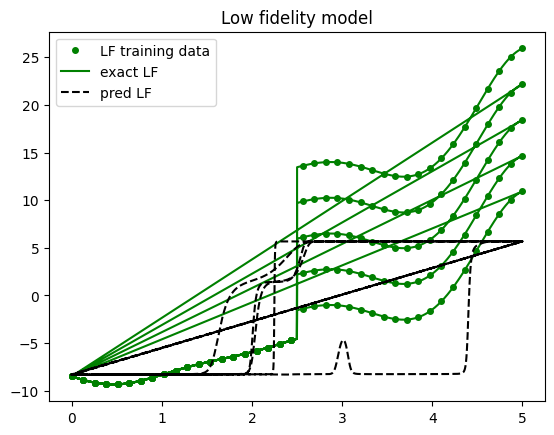

In [5]:
# parameters of the Neural Network
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
definition_LF={
        "network_type": "LF",
        "params": bestLF_params,
        "data_train": data["xlf"],
        "output_train": data["Ylf"],
        "N": data["NepoLF"],
        "n": data["Nlf"],
        "train": True,
        "do_HPO": False,
        "verbose": False
    }
# building of the neural network
modelLF=NetworkFactory.build_network(**definition_LF)
# prediction step
yLF=modelLF.prediction(data["datatest"])
(mse_LF,R2_LF)=modelLF.performance(data["datatest"],data["modified_highfid"](data["datatest"][:,0],data["datatest"][:,1]))

# Plot of the estimated results
plt.figure()
plt.plot(data["xlf"][:,0],data["Ylf"],'go', label = 'LF training data', markersize = 4)
plt.plot(data["datatest"][:,0],data["modified_lowfid"](data["datatest"][:,0],data["datatest"][:,1]),'g', label = 'exact LF') 
plt.plot(data["datatest"][:,0],yLF,'k--', label = 'pred LF')
plt.legend()
plt.title('Low fidelity model')


Text(0.5, 1.0, 'Low fidelity model')

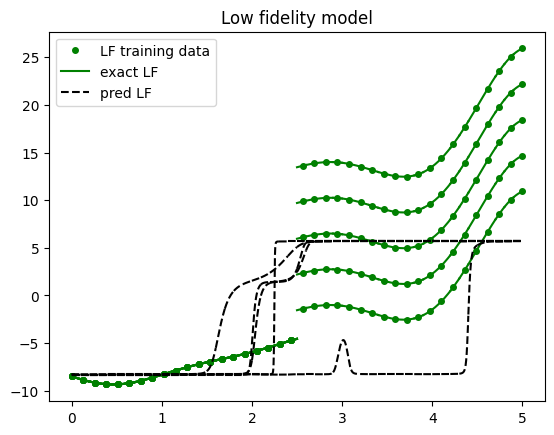

In [8]:
plt.figure()

# Plot LF training data
plt.plot(data["xlf"][:,0], data["Ylf"], 'go', label='LF training data', markersize=4)

# Plot exact LF, but split the lines where needed
for i in range(data["datatest"].shape[0] // data["Ylf"].shape[0]):  # Assuming a consistent number of points per line
    plt.plot(data["datatest"][i*data["Ylf"].shape[0]:(i+1)*data["Ylf"].shape[0], 0], 
             data["modified_lowfid"](data["datatest"][i*data["Ylf"].shape[0]:(i+1)*data["Ylf"].shape[0], 0], 
             data["datatest"][i*data["Ylf"].shape[0]:(i+1)*data["Ylf"].shape[0], 1]), 'g', label='exact LF' if i == 0 else "")

# Plot pred LF, splitting the lines similarly
for i in range(data["datatest"].shape[0] // data["Ylf"].shape[0]):
    plt.plot(data["datatest"][i*data["Ylf"].shape[0]:(i+1)*data["Ylf"].shape[0], 0], 
             yLF[i*data["Ylf"].shape[0]:(i+1)*data["Ylf"].shape[0]], 'k--', label='pred LF' if i == 0 else "")

plt.legend()
plt.title('Low fidelity model')

Function training took 88.6710 seconds
The function training took 88.67099356651306 seconds.


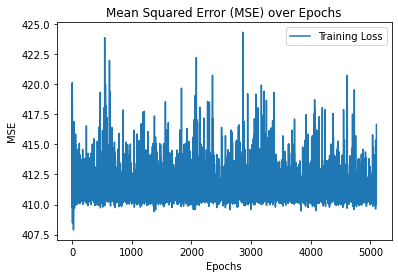

Test MSE: 391.80286709300026
R^2: 0.07458920538065117


Text(0.5, 1.0, 'High fidelity model')

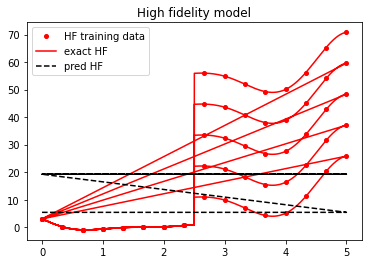

In [7]:
# parameters of the Neural Network
bestHF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
definition_HF={
        "network_type": "LF",
        "params": bestLF_params,
        "data_train": data["xhf"],
        "output_train": data["Yhf"],
        "N": data["NepoHF"],
        "n": data["Nhf"],
        "train": True,
        "do_HPO": False,
        "verbose": False
    }
modelHF=NetworkFactory.build_network(**definition_HF)
yHF=modelHF.prediction(data["datatest"])
(mse_HF,R2_HF)=modelHF.performance(data["datatest"],data["modified_highfid"](data["datatest"][:,0],data["datatest"][:,1]))

# Plot of the estimated results
plt.figure()
plt.plot(data["xhf"][:,0],data["Yhf"],'ro', label = 'HF training data', markersize = 4)
plt.plot(data["datatest"][:,0],data["modified_highfid"](data["datatest"][:,0],data["datatest"][:,1]),'r', label = 'exact HF') 
plt.plot(data["datatest"][:,0],yHF,'k--', label = 'pred HF')
plt.legend()
plt.title('High fidelity model')



The function training took 37.323015 seconds.


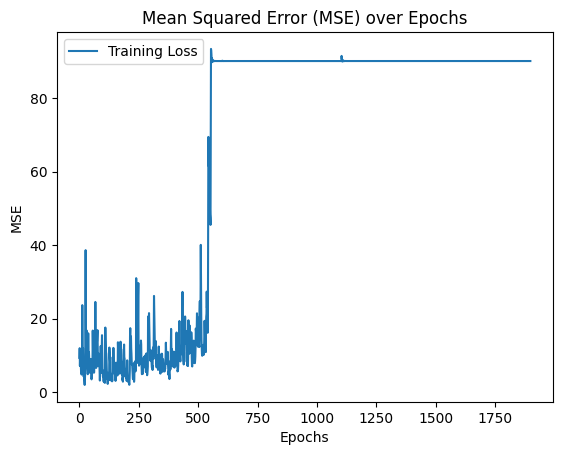

The function training took 98.634896 seconds.


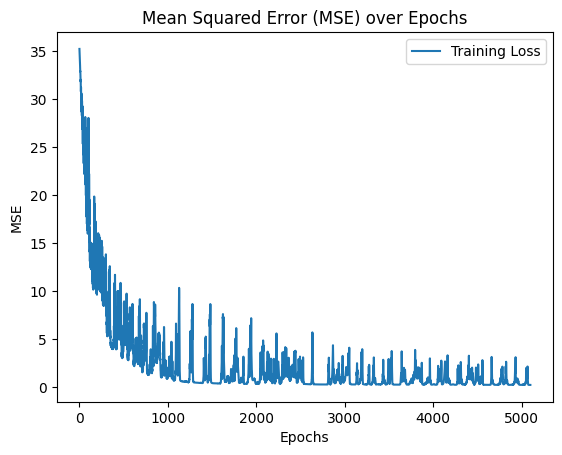

Test MSE: 6.497820377916394
R^2: 0.9846526056232404


Text(0.5, 1.0, 'High fidelity model')

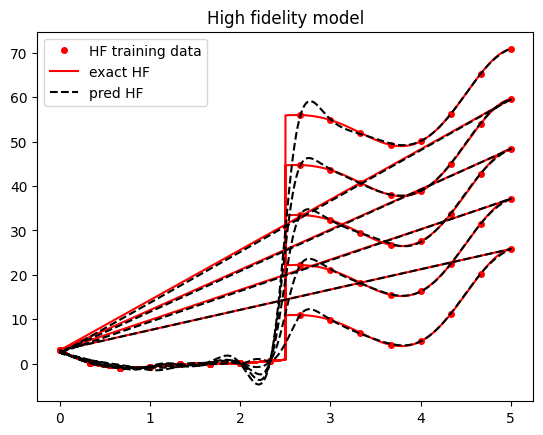

In [6]:
### 2 steps NEURAL NETWORK ###
# collection of parameters
bestLF_params = {
    'lr': 0.0255, 
    'kernel_init': 'glorot_uniform', 
    'opt': 'Adam'
}

best_params = {
    'kernel_init': 'uniform', 
    'l2weight': 0.00010018625799978436, 
    'lr': 0.07093837044166487, 
    'nodes': 74.0, 
    'opt': 'Adamax'
}

params = [bestLF_params, best_params]

N = [data["NepoLF"], data["NepoHF"]]
n = [data["Nlf"], data["Nhf"]]

# names of the networks 
names = ['LF', 'HF']

# collection of the parameters
definition_2steps = {
    "network_type": "2step",
    "names": names,
    "params": params,
    "data_train": [data["xlf"], data["xhf"]],
    "output_train": [data["Ylf"], data["Yhf"]],
    "N": N,
    "n": n,
    "train": True,
    "do_HPO": False,
    "verbose": False
}

# creation of 2 steps model 
final_model = NetworkFactory.build_network(**definition_2steps)


y_test=final_model.prediction(data["datatest"])

(mse_MF,R_MF)=final_model.performance(data["datatest"],data["modified_highfid"](data["datatest"][:,0],data["datatest"][:,1]))

    #(mse_MF,R_MF)=final_model.performance(data["x_test"].reshape(-1,1),data["high_fid"](data["x_test"]))

### PLOT of predicted models ###
#LF single-fidelity



plt.figure()
plt.plot(data["xhf"][:,0],data["Yhf"],'ro', label = 'HF training data', markersize = 4)
plt.plot(data["datatest"][:,0],data["modified_highfid"](data["datatest"][:,0],data["datatest"][:,1]),'r', label = 'exact HF') 
plt.plot(data["datatest"][:,0],y_test,'k--', label = 'pred HF')
plt.legend()
plt.title('High fidelity model')


# Prediction of a parameter 2 step nn

Sampling chain 1/2


Running chain, α = 0.25: 100%|██████████| 300/300 [00:20<00:00, 14.82it/s]


Sampling chain 2/2


Running chain, α = 0.25: 100%|██████████| 300/300 [00:11<00:00, 25.19it/s]
c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [7.977]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  7.977  0.539   7.094    8.908      0.083    0.059      36.0      19.0   

    r_hat  
x0   1.09  
Autocorrelation...
The difference between estimated values [7.023]



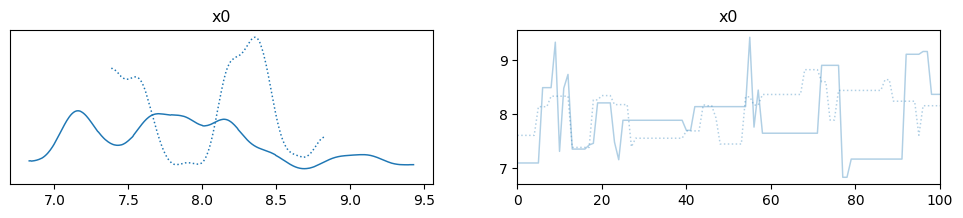

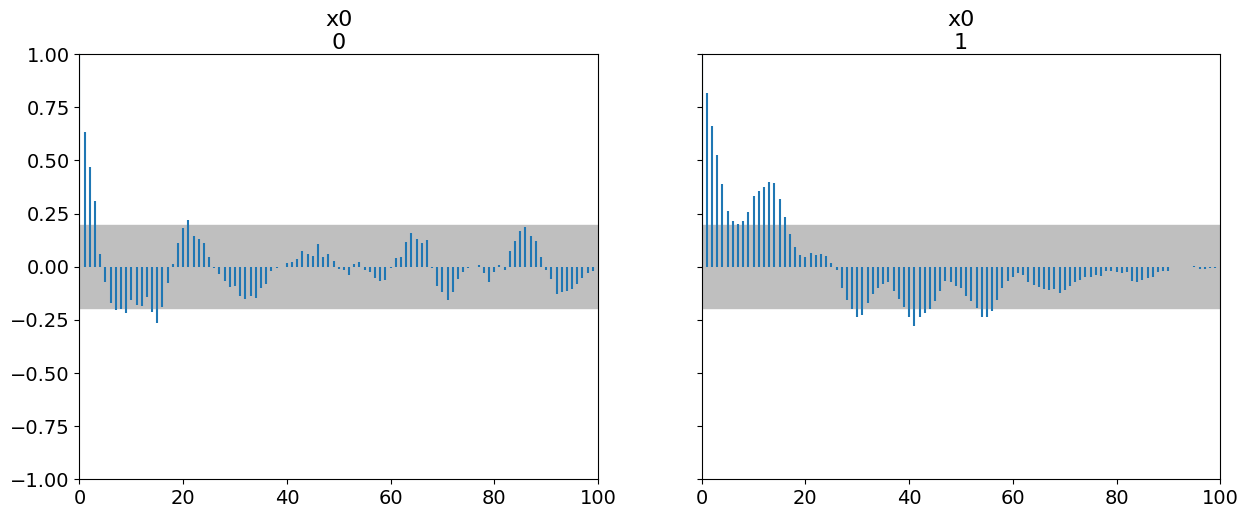

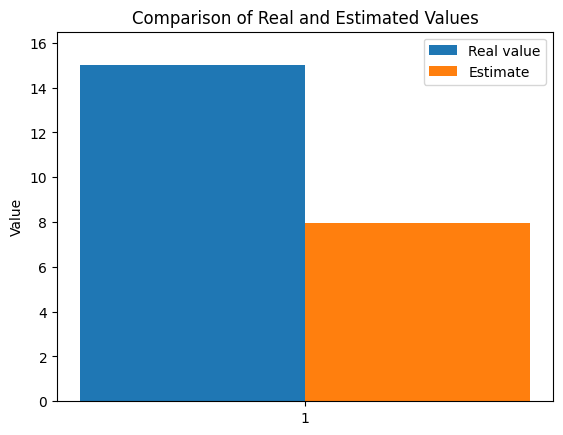

The function param_inverse took 32.968816 seconds.
Sampling chain 1/2


Running chain, α = 0.47: 100%|██████████| 300/300 [00:12<00:00, 23.15it/s]


Sampling chain 2/2


Running chain, α = 0.41: 100%|██████████| 300/300 [00:13<00:00, 22.99it/s]
c:\Users\Giacomo\miniconda3\Lib\site-packages\arviz\data\inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [7.89]
    mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  7.89  0.619   6.785    8.719      0.197    0.149      10.0      45.0   

    r_hat  
x0   1.18  
Autocorrelation...
The difference between estimated values [7.11]



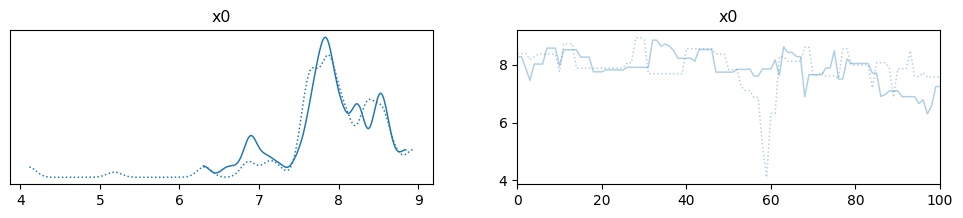

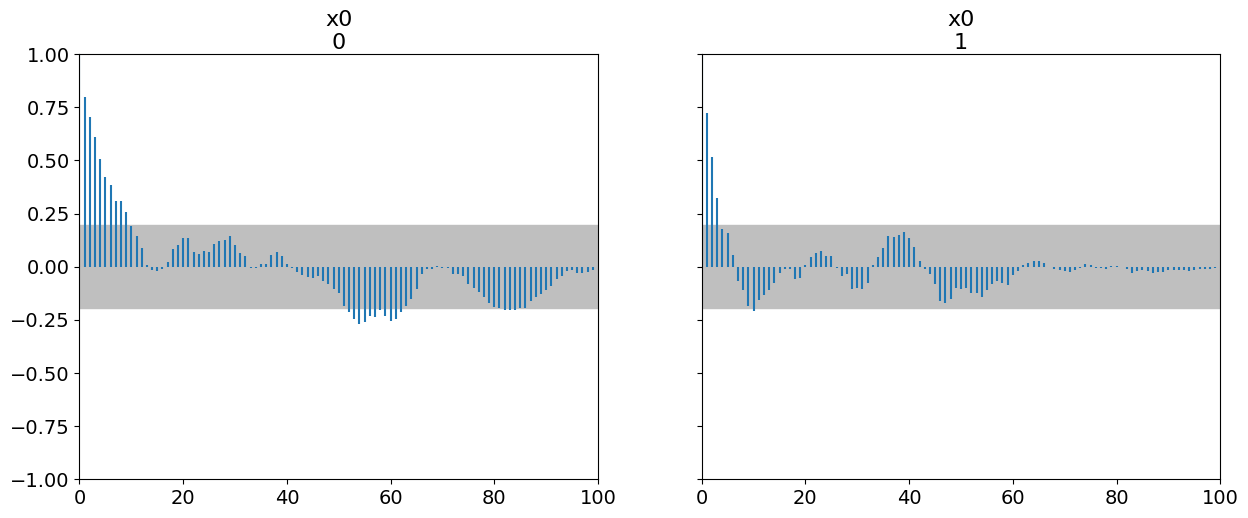

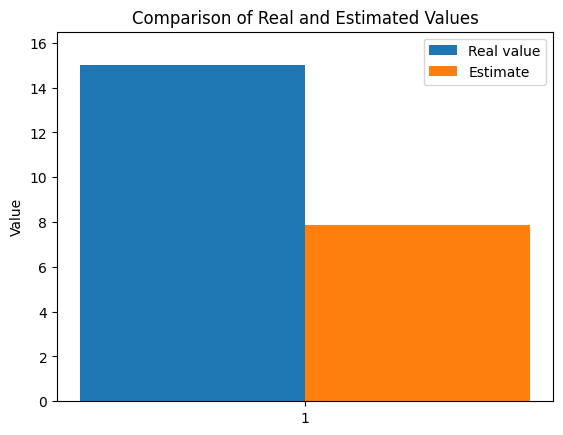

The function param_inverse took 26.483543 seconds.
Sampling chain 1/2


Running chain, α = 0.51:  38%|███▊      | 113/300 [00:05<00:08, 22.03it/s]


KeyboardInterrupt: 

In [7]:
mean_prior = np.array([7.])
cov_prior = np.diag([1.])

sigma_noise = [0.05,0.1]
n_data = [50,30]
parameters = np.array([15.])
sigma = np.array([ 4.,2.])
rwmh_scaling = np.array([ 2.,0.5,1.])
rwmh_cov = np.eye(1)
rwmh_adaptive = True
iterations = 3000
burnin = 2000
n_chains = 2
algo = "MH"

# ricorda che i primi due non vanno bene in qualunque caso
estimateLF, errorLF= run_simulation(data["xhf"], mean_prior, cov_prior, data["Yhf"], sigma_noise, n_data, parameters, sigma, rwmh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, modelLF,algo)
estimateHF, errorHF= run_simulation(data["xhf"], mean_prior, cov_prior, data["Yhf"], sigma_noise, n_data, parameters, sigma, rwmh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, modelHF,algo)

estimateMF, errorMF= run_simulation(data["xhf"], mean_prior, cov_prior, data["Yhf"], sigma_noise, n_data, parameters, sigma, rwmh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, final_model,algo)




Sampling chain 1/2


Running chain, α = 0.28: 100%|██████████| 3000/3000 [04:45<00:00, 10.50it/s]


Sampling chain 2/2


Running chain, α = 0.24: 100%|██████████| 3000/3000 [05:10<00:00,  9.65it/s]
C:\Users\Giacomo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


Estimated values are [14.365]
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  14.365  0.273  13.858   14.884      0.014     0.01     363.0     285.0   

    r_hat  
x0    1.0  
Autocorrelation...
the difference between estimated values [0.635]



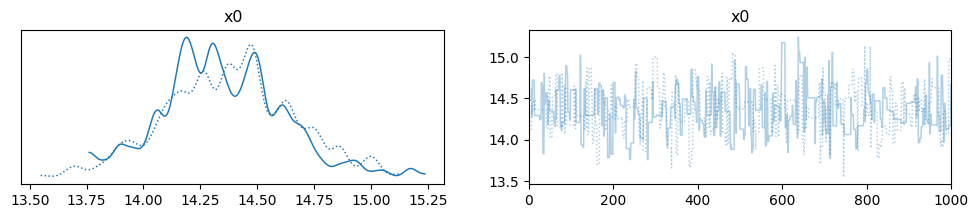

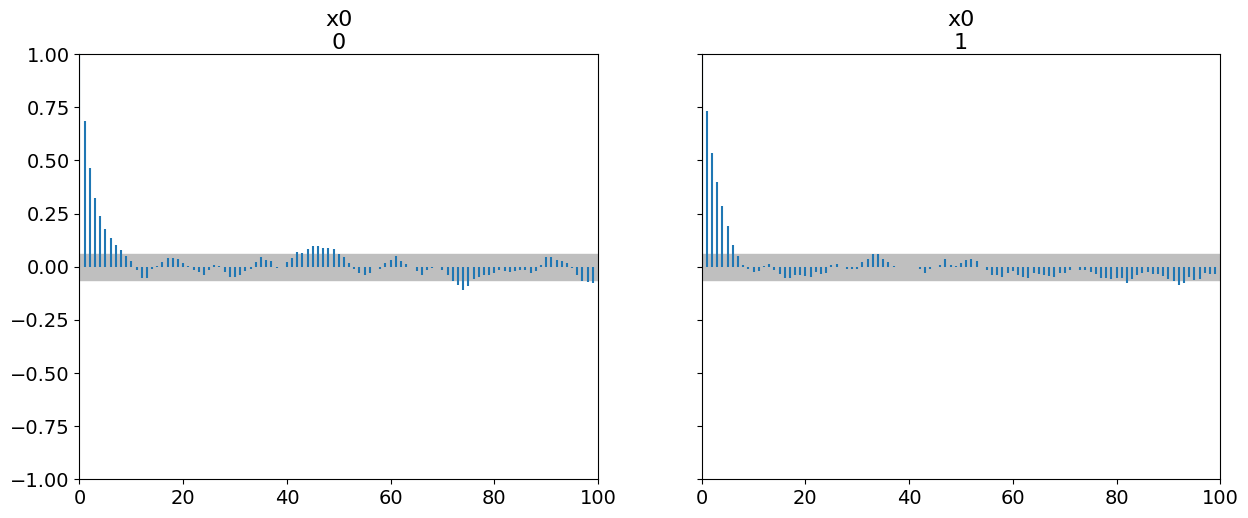

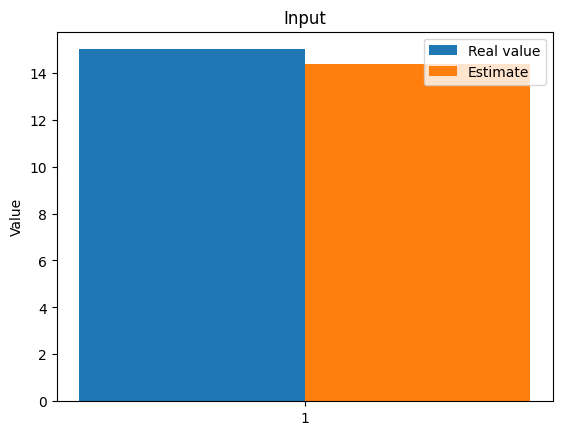

The function param_inverse took 610.8145380020142 seconds.
Sampling chain 1/2


Running chain, α = 0.27:  24%|██▍       | 720/3000 [01:16<04:03,  9.38it/s]


KeyboardInterrupt: 

In [10]:
mean_prior = np.array([7.])
cov_prior = np.diag([1.])

sigma_noise = [0.05,0.1]
n_data = [50,30]
parameters = np.array([15.])
sigma = np.array([ 4.,2.])
rwmh_scaling = np.array([ 2.,0.5,1.])
rwmh_cov = np.eye(1)
rwmh_adaptive = True
iterations = 3000
burnin = 2000
n_chains = 2
algo = "MH"

# ricorda che i primi due non vanno bene in qualunque caso
estimateLF, errorLF= run_simulation(data["xhf"], mean_prior, cov_prior, data["Yhf"], sigma_noise, n_data, parameters, sigma, rwmh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, modelLF,algo)
estimateHF, errorHF= run_simulation(data["xhf"], mean_prior, cov_prior, data["Yhf"], sigma_noise, n_data, parameters, sigma, rwmh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, modelHF,algo)

estimateMF, errorMF= run_simulation(data["xhf"], mean_prior, cov_prior, data["Yhf"], sigma_noise, n_data, parameters, sigma, rwmh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, final_model,algo)




In [11]:

# Define inputs
mean_prior = np.array([7.])
cov_prior = np.diag([1.])
y_obs = data["Yhf"]
sd_noise = 0.1
N = 3000
burn_in = 2000
number_chains = 2
algo = "MH"
x_real = np.array([15.])
proposal_sd = 0.3
adapt = True
n_data = [30, 50]


x_data=  np.linspace(0., 5., n_data[0]).reshape(-1, 1)  # Generate evaluation times

nearest_x, y_obs = process_data(data["xhf"], parameters, x_data, Yhf) 

estimates = final_model.inverse_cuqi(
    mean_prior=mean_prior,
    x_real=x_real,
    y_obs=y_obs,
    N=N,
    burn_in=burn_in,
    cov_prior=cov_prior,
    sd_noise=sd_noise,  
    adapt=adapt,
    scale=proposal_sd,
    proposal_sd=proposal_sd,
    number_chains=number_chains,
    algo=algo,
    x_data=x_data
)

NameError: name 'parameters' is not defined

In [26]:
data["Yhf"].shape

(80,)

In [ ]:
mean_prior = np.array([7.])
cov_prior = np.diag([1.])
Yhf = np.array([10, 20, 30, 40, 50])
sigma_noise = [0.1, 0.05]
n_data = [30, 50]
parameters = np.array([15.])
sigma = np.array([2., 4.])
rwmh_scaling = np.array([0.5, 1., 2.])
rwmh_cov = np.eye(1)
rwmh_adaptive = True
iterations = 3000
burnin = 2000
n_chains = 2
algo = "MH"


Keras weights file (<HDF5 file "variables.h5" (mode r+)>) saving:
...layers\dense
......vars
.........0
.........1
...layers\dense_1
......vars
.........0
.........1
...layers\dense_2
......vars
.........0
.........1
...layers\dense_3
......vars
.........0
.........1
...layers\dense_4
......vars
.........0
.........1
...layers\input_layer
......vars
...metrics\mean
......vars
.........0
.........1
...metrics\mean_metric_wrapper
......vars
.........0
.........1
...optimizer
......vars
.........0
.........1
.........10
.........11
.........12
.........13
.........14
.........15
.........16
.........17
.........18
.........19
.........2
.........20
.........21
.........22
.........23
.........24
.........25
.........26
.........27
.........28
.........29
.........3
.........30
.........4
.........5
.........6
.........7
.........8
.........9
...vars
Keras model archive saving:
File Name                                             Modified             Size
config.json                     

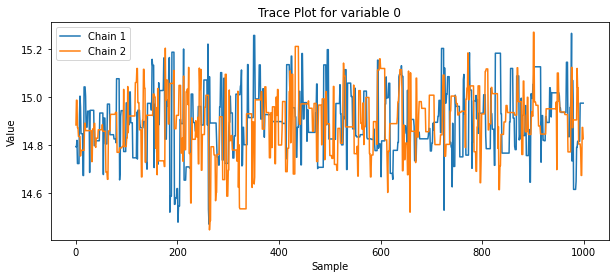

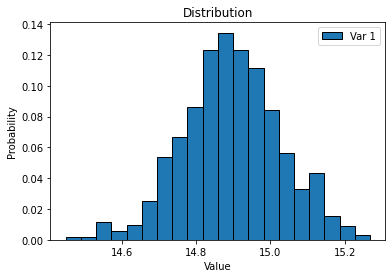

c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\utils.py:187: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  numba_fn = numba.jit(**self.kwargs)(self.function)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 368.5176640330527


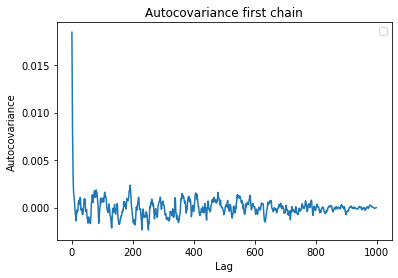

The difference between estimated values [0.1035326]



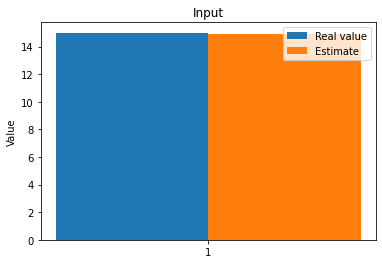


Keras weights file (<HDF5 file "variables.h5" (mode r+)>) saving:
...layers\dense
......vars
.........0
.........1
...layers\dense_1
......vars
.........0
.........1
...layers\dense_2
......vars
.........0
.........1
...layers\dense_3
......vars
.........0
.........1
...layers\dense_4
......vars
.........0
.........1
...layers\input_layer
......vars
...metrics\mean
......vars
.........0
.........1
...metrics\mean_metric_wrapper
......vars
.........0
.........1
...optimizer
......vars
.........0
.........1
.........10
.........11
.........12
.........13
.........14
.........15
.........16
.........17
.........18
.........19
.........2
.........20
.........21
.........22
.........23
.........24
.........25
.........26
.........27
.........28
.........29
.........3
.........30
.........4
.........5
.........6
.........7
.........8
.........9
...vars
Keras model archive saving:
File Name                                             Modified             Size
config.json                     

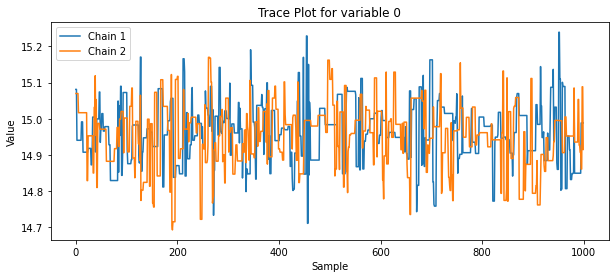

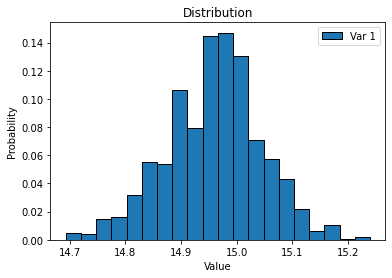

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 419.747898843593


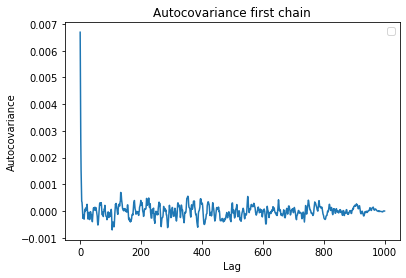

The difference between estimated values [0.04093855]



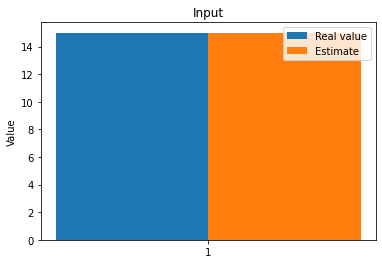


Keras weights file (<HDF5 file "variables.h5" (mode r+)>) saving:
...layers\dense
......vars
.........0
.........1
...layers\dense_1
......vars
.........0
.........1
...layers\dense_2
......vars
.........0
.........1
...layers\dense_3
......vars
.........0
.........1
...layers\dense_4
......vars
.........0
.........1
...layers\input_layer
......vars
...metrics\mean
......vars
.........0
.........1
...metrics\mean_metric_wrapper
......vars
.........0
.........1
...optimizer
......vars
.........0
.........1
.........10
.........11
.........12
.........13
.........14
.........15
.........16
.........17
.........18
.........19
.........2
.........20
.........21
.........22
.........23
.........24
.........25
.........26
.........27
.........28
.........29
.........3
.........30
.........4
.........5
.........6
.........7
.........8
.........9
...vars
Keras model archive saving:
File Name                                             Modified             Size
config.json                     

KeyboardInterrupt: 

Sample 900 / 3000ion_parallel pid=17772) 
Sample 930 / 3000 [repeated 2x across cluster]
Sample 960 / 3000 [repeated 2x across cluster]
Sample 990 / 3000 [repeated 2x across cluster]
Sample 1020 / 3000 [repeated 2x across cluster]
Sample 1080 / 3000 [repeated 4x across cluster]


In [6]:
# Define inputs
mean_prior = np.array([7.])
cov_prior = np.diag([1.])
Yhf = data["Yhf"]
sd_noise = [0.1,0.05]
N = 3000
burn_in = 2000
number_chains = 2
algo = "MH"
x_real = np.array([15.])
proposal_sd = [4.,2.]
adapt = True
n_data = [50,30]


module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure2.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)

x_data=  np.linspace(0., 5., n_data[0]).reshape(-1, 1)  # Generate evaluation times
nearest_x, y_obs = process_data(data["xhf"], x_real, x_data, Yhf) 

# estimates = final_model.inverse_cuqi(
#     mean_prior=mean_prior,
#     x_real=x_real,
#     y_obs=y_obs,
#     N=N,
#     burn_in=burn_in,
#     cov_prior=cov_prior,
#     sd_noise=sd_noise,  
#     adapt=adapt,
#     scale=proposal_sd,
#     proposal_sd=proposal_sd,
#     number_chains=number_chains,
#     algo=algo,
#     x_data=x_data
# )
estimates=run_simulation_cuqi(data,
    mean_prior,
    x_real,
    N,
    burn_in,
    cov_prior,
    sd_noise,  
    adapt,
    
    proposal_sd,
    number_chains,
    algo,
    x_data,
    n_data,
    final_model,
    parallel=True
) 



Keras weights file (<HDF5 file "variables.h5" (mode r+)>) saving:
...layers\dense
......vars
.........0
.........1
...layers\dense_1
......vars
.........0
.........1
...layers\dense_2
......vars
.........0
.........1
...layers\dense_3
......vars
.........0
.........1
...layers\dense_4
......vars
.........0
.........1
...layers\input_layer
......vars
...metrics\mean
......vars
.........0
.........1
...metrics\mean_metric_wrapper
......vars
.........0
.........1
...optimizer
......vars
.........0
.........1
.........10
.........11
.........12
.........13
.........14
.........15
.........16
.........17
.........18
.........19
.........2
.........20
.........21
.........22
.........23
.........24
.........25
.........26
.........27
.........28
.........29
.........3
.........30
.........4
.........5
.........6
.........7
.........8
.........9
...vars
Keras model archive saving:
File Name                                             Modified             Size
config.json                     

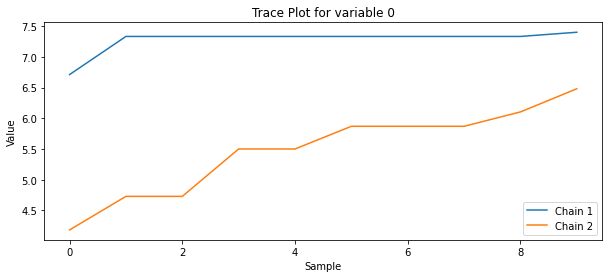

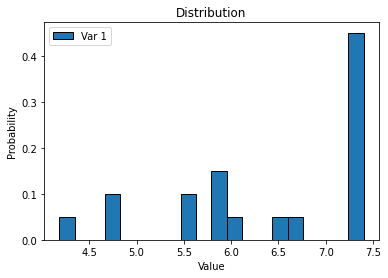

c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\utils.py:187: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  numba_fn = numba.jit(**self.kwargs)(self.function)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 5.5962239196361825


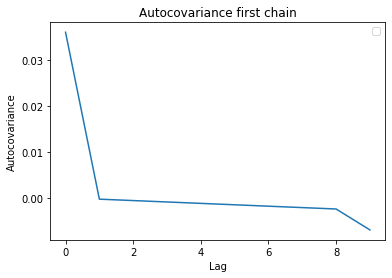

The difference between estimated values [8.61983859]



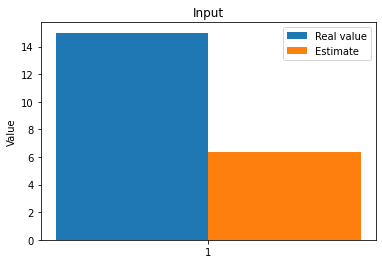


Keras weights file (<HDF5 file "variables.h5" (mode r+)>) saving:
...layers\dense
......vars
.........0
.........1
...layers\dense_1
......vars
.........0
.........1
...layers\dense_2
......vars
.........0
.........1
...layers\dense_3
......vars
.........0
.........1
...layers\dense_4
......vars
.........0
.........1
...layers\input_layer
......vars
...metrics\mean
......vars
.........0
.........1
...metrics\mean_metric_wrapper
......vars
.........0
.........1
...optimizer
......vars
.........0
.........1
.........10
.........11
.........12
.........13
.........14
.........15
.........16
.........17
.........18
.........19
.........2
.........20
.........21
.........22
.........23
.........24
.........25
.........26
.........27
.........28
.........29
.........3
.........30
.........4
.........5
.........6
.........7
.........8
.........9
...vars
Keras model archive saving:
File Name                                             Modified             Size
config.json                     

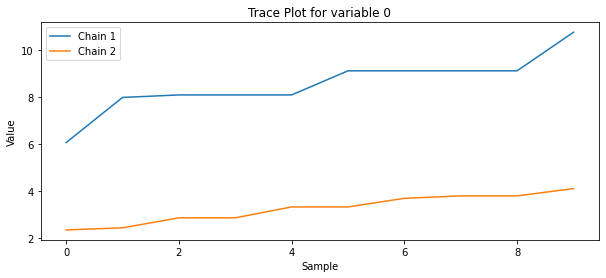

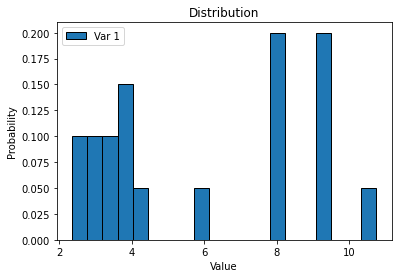

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 5.374448121024876


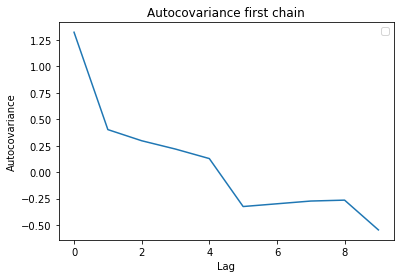

The difference between estimated values [9.09810614]



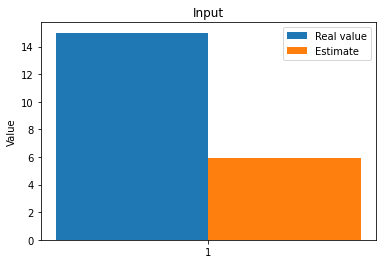


Keras weights file (<HDF5 file "variables.h5" (mode r+)>) saving:
...layers\dense
......vars
.........0
.........1
...layers\dense_1
......vars
.........0
.........1
...layers\dense_2
......vars
.........0
.........1
...layers\dense_3
......vars
.........0
.........1
...layers\dense_4
......vars
.........0
.........1
...layers\input_layer
......vars
...metrics\mean
......vars
.........0
.........1
...metrics\mean_metric_wrapper
......vars
.........0
.........1
...optimizer
......vars
.........0
.........1
.........10
.........11
.........12
.........13
.........14
.........15
.........16
.........17
.........18
.........19
.........2
.........20
.........21
.........22
.........23
.........24
.........25
.........26
.........27
.........28
.........29
.........3
.........30
.........4
.........5
.........6
.........7
.........8
.........9
...vars
Keras model archive saving:
File Name                                             Modified             Size
config.json                     

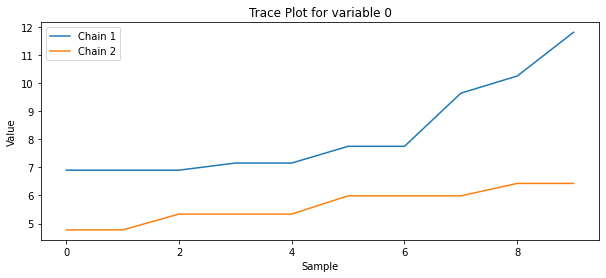

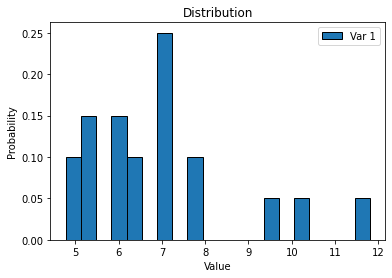

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 5.301566609598665


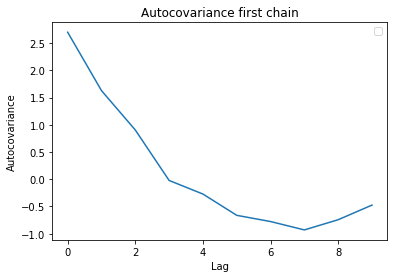

The difference between estimated values [8.06996134]



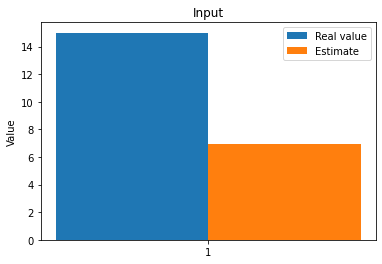


Keras weights file (<HDF5 file "variables.h5" (mode r+)>) saving:
...layers\dense
......vars
.........0
.........1
...layers\dense_1
......vars
.........0
.........1
...layers\dense_2
......vars
.........0
.........1
...layers\dense_3
......vars
.........0
.........1
...layers\dense_4
......vars
.........0
.........1
...layers\input_layer
......vars
...metrics\mean
......vars
.........0
.........1
...metrics\mean_metric_wrapper
......vars
.........0
.........1
...optimizer
......vars
.........0
.........1
.........10
.........11
.........12
.........13
.........14
.........15
.........16
.........17
.........18
.........19
.........2
.........20
.........21
.........22
.........23
.........24
.........25
.........26
.........27
.........28
.........29
.........3
.........30
.........4
.........5
.........6
.........7
.........8
.........9
...vars
Keras model archive saving:
File Name                                             Modified             Size
config.json                     

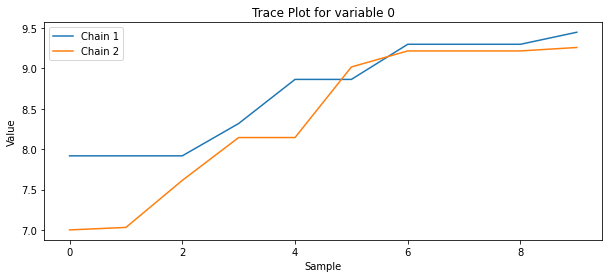

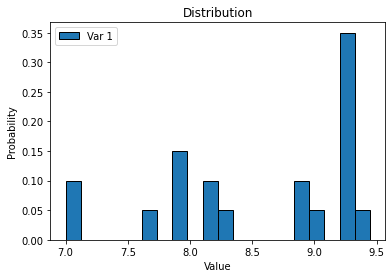

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 5.9845529927199355


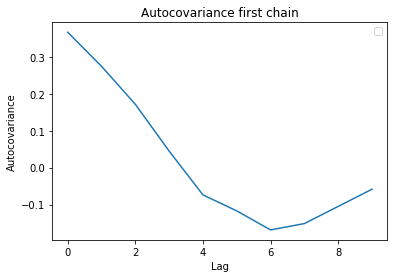

The difference between estimated values [6.44978958]



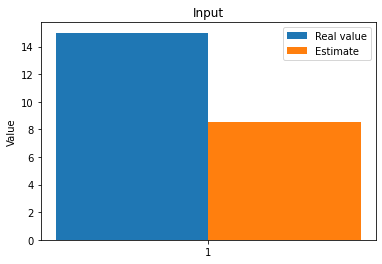


Keras weights file (<HDF5 file "variables.h5" (mode r+)>) saving:
...layers\dense
......vars
.........0
.........1
...layers\dense_1
......vars
.........0
.........1
...layers\dense_2
......vars
.........0
.........1
...layers\dense_3
......vars
.........0
.........1
...layers\dense_4
......vars
.........0
.........1
...layers\input_layer
......vars
...metrics\mean
......vars
.........0
.........1
...metrics\mean_metric_wrapper
......vars
.........0
.........1
...optimizer
......vars
.........0
.........1
.........10
.........11
.........12
.........13
.........14
.........15
.........16
.........17
.........18
.........19
.........2
.........20
.........21
.........22
.........23
.........24
.........25
.........26
.........27
.........28
.........29
.........3
.........30
.........4
.........5
.........6
.........7
.........8
.........9
...vars
Keras model archive saving:
File Name                                             Modified             Size
config.json                     

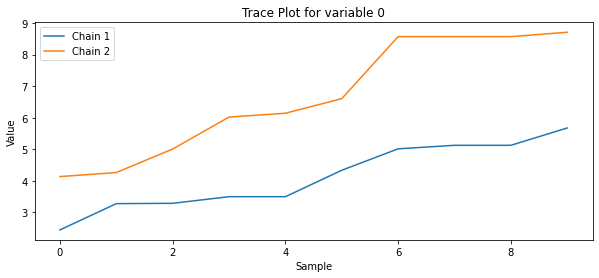

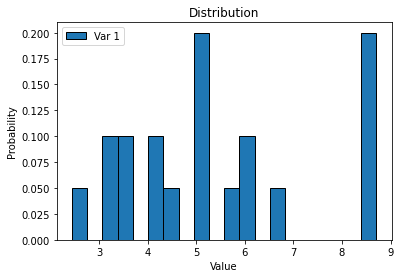

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 5.568997826475344


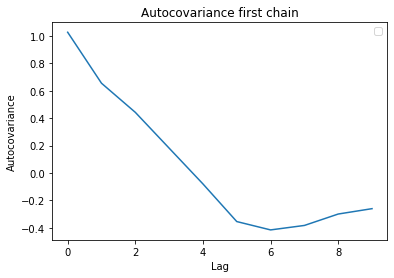

The difference between estimated values [9.60459708]



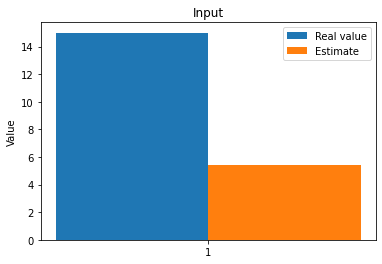


Keras weights file (<HDF5 file "variables.h5" (mode r+)>) saving:
...layers\dense
......vars
.........0
.........1
...layers\dense_1
......vars
.........0
.........1
...layers\dense_2
......vars
.........0
.........1
...layers\dense_3
......vars
.........0
.........1
...layers\dense_4
......vars
.........0
.........1
...layers\input_layer
......vars
...metrics\mean
......vars
.........0
.........1
...metrics\mean_metric_wrapper
......vars
.........0
.........1
...optimizer
......vars
.........0
.........1
.........10
.........11
.........12
.........13
.........14
.........15
.........16
.........17
.........18
.........19
.........2
.........20
.........21
.........22
.........23
.........24
.........25
.........26
.........27
.........28
.........29
.........3
.........30
.........4
.........5
.........6
.........7
.........8
.........9
...vars
Keras model archive saving:
File Name                                             Modified             Size
config.json                     

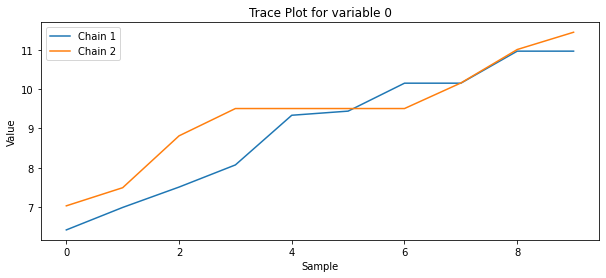

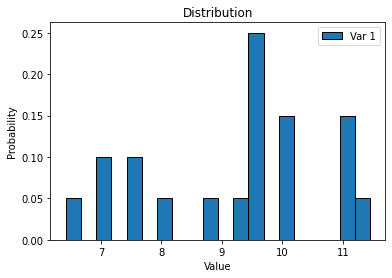

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 6.493459317203905


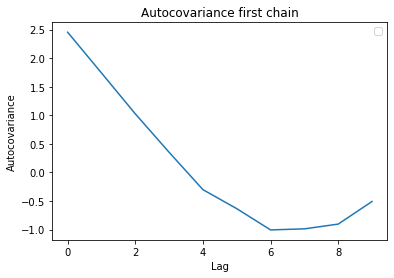

The difference between estimated values [5.80119598]



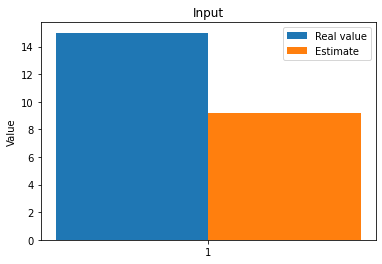


Keras weights file (<HDF5 file "variables.h5" (mode r+)>) saving:
...layers\dense
......vars
.........0
.........1
...layers\dense_1
......vars
.........0
.........1
...layers\dense_2
......vars
.........0
.........1
...layers\dense_3
......vars
.........0
.........1
...layers\dense_4
......vars
.........0
.........1
...layers\input_layer
......vars
...metrics\mean
......vars
.........0
.........1
...metrics\mean_metric_wrapper
......vars
.........0
.........1
...optimizer
......vars
.........0
.........1
.........10
.........11
.........12
.........13
.........14
.........15
.........16
.........17
.........18
.........19
.........2
.........20
.........21
.........22
.........23
.........24
.........25
.........26
.........27
.........28
.........29
.........3
.........30
.........4
.........5
.........6
.........7
.........8
.........9
...vars
Keras model archive saving:
File Name                                             Modified             Size
config.json                     

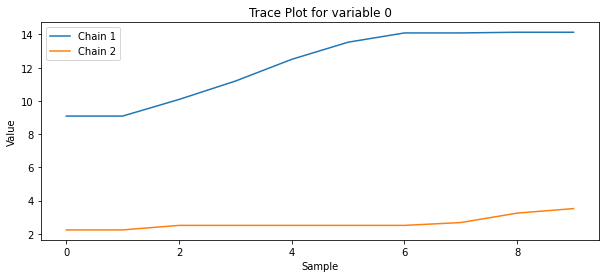

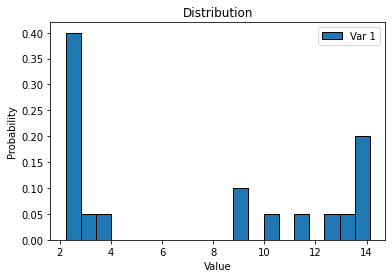

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 5.410583114872969


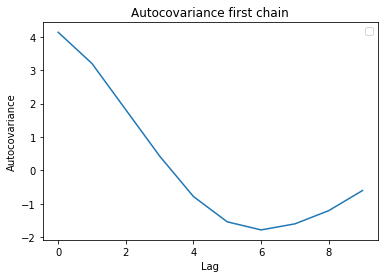

The difference between estimated values [7.57928646]



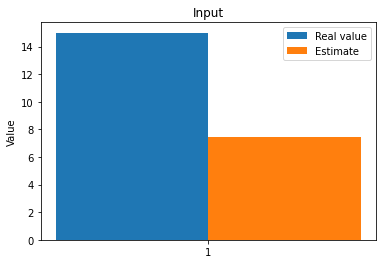


Keras weights file (<HDF5 file "variables.h5" (mode r+)>) saving:
...layers\dense
......vars
.........0
.........1
...layers\dense_1
......vars
.........0
.........1
...layers\dense_2
......vars
.........0
.........1
...layers\dense_3
......vars
.........0
.........1
...layers\dense_4
......vars
.........0
.........1
...layers\input_layer
......vars
...metrics\mean
......vars
.........0
.........1
...metrics\mean_metric_wrapper
......vars
.........0
.........1
...optimizer
......vars
.........0
.........1
.........10
.........11
.........12
.........13
.........14
.........15
.........16
.........17
.........18
.........19
.........2
.........20
.........21
.........22
.........23
.........24
.........25
.........26
.........27
.........28
.........29
.........3
.........30
.........4
.........5
.........6
.........7
.........8
.........9
...vars
Keras model archive saving:
File Name                                             Modified             Size
config.json                     

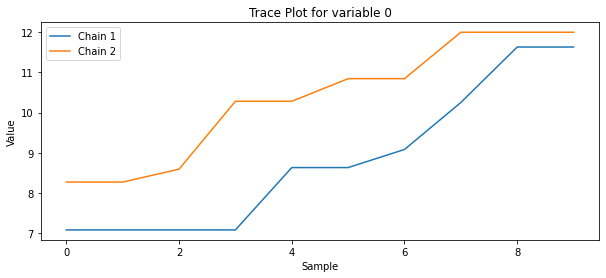

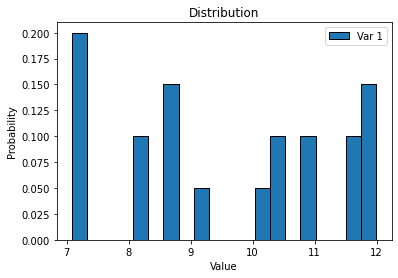

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 5.938966005869989


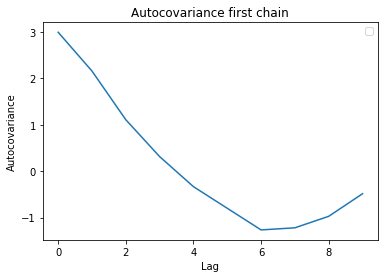

The difference between estimated values [5.42003317]



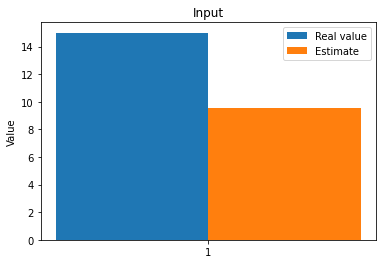

In [5]:
# Define inputs
mean_prior = np.array([7.])
cov_prior = np.diag([1.])
Yhf = data["Yhf"]
sd_noise = [0.1,0.05]
N = 30
burn_in = 20
number_chains = 2
algo = "MH"
x_real = np.array([15.])
proposal_sd = [4.,2.]
adapt = True
n_data = [50,30]


module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure2.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)

x_data=  np.linspace(0., 5., n_data[0]).reshape(-1, 1)  # Generate evaluation times
nearest_x, y_obs = process_data(data["xhf"], x_real, x_data, Yhf) 

# estimates = final_model.inverse_cuqi(
#     mean_prior=mean_prior,
#     x_real=x_real,
#     y_obs=y_obs,
#     N=N,
#     burn_in=burn_in,
#     cov_prior=cov_prior,
#     sd_noise=sd_noise,  
#     adapt=adapt,
#     scale=proposal_sd,
#     proposal_sd=proposal_sd,
#     number_chains=number_chains,
#     algo=algo,
#     x_data=x_data
# )
estimates=run_simulation_cuqi(data,
    mean_prior,
    x_real,
    N,
    burn_in,
    cov_prior,
    sd_noise,  
    adapt,
    
    proposal_sd,
    number_chains,
    algo,
    x_data,
    n_data,
    final_model,
    parallel=True
) 


2024-08-01 11:31:06,362	ERROR services.py:1347 -- Failed to start the dashboard 
2024-08-01 11:31:06,366	ERROR services.py:1372 -- Error should be written to 'dashboard.log' or 'dashboard.err'. We are printing the last 20 lines for you. See 'https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#logging-directory-structure' to find where the log file is.
2024-08-01 11:31:06,377	ERROR services.py:1382 -- Couldn't read dashboard.log file. Error: [Errno 2] No such file or directory: 'C:\\Users\\Giacomo\\AppData\\Local\\Temp\\ray\\session_2024-08-01_11-30-43_807988_6852\\logs\\dashboard.log'. It means the dashboard is broken even before it initializes the logger (mostly dependency issues). Reading the dashboard.err file which contains stdout/stderr.
2024-08-01 11:31:06,385	ERROR services.py:1416 -- Failed to read dashboard.err file: cannot mmap an empty file. It is unexpected. Please report an issue to Ray github. https://github.com/ray-project/ray/issues
2024-0

Keras weights file (<HDF5 file "variables.h5" (mode r+)>) saving:
...layers\dense
......vars
.........0
.........1
...layers\dense_1
......vars
.........0
.........1
...layers\dense_2
......vars
.........0
.........1
...layers\dense_3
......vars
.........0
.........1
...layers\dense_4
......vars
.........0
.........1
...layers\input_layer
......vars
...metrics\mean
......vars
.........0
.........1
...metrics\mean_metric_wrapper
......vars
.........0
.........1
...optimizer
......vars
.........0
.........1
.........10
.........11
.........12
.........13
.........14
.........15
.........16
.........17
.........18
.........19
.........2
.........20
.........21
.........22
.........23
.........24
.........25
.........26
.........27
.........28
.........29
.........3
.........30
.........4
.........5
.........6
.........7
.........8
.........9
...vars
Keras model archive saving:
File Name                                             Modified             Size
config.json                      

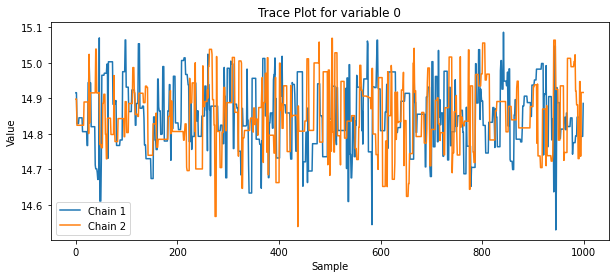

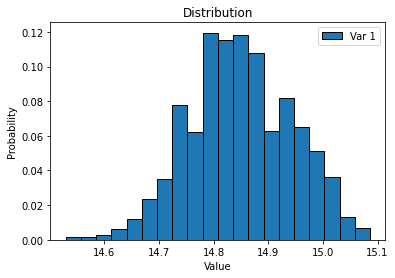

c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\utils.py:187: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  numba_fn = numba.jit(**self.kwargs)(self.function)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 389.74648181640333


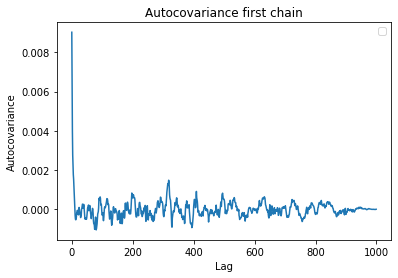

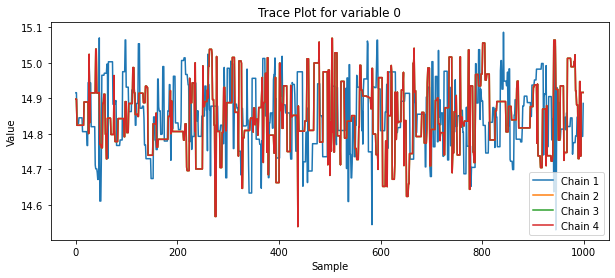

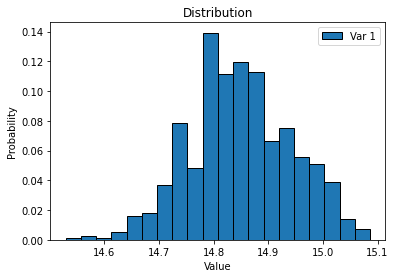

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


ESS values = 803.7112463086754


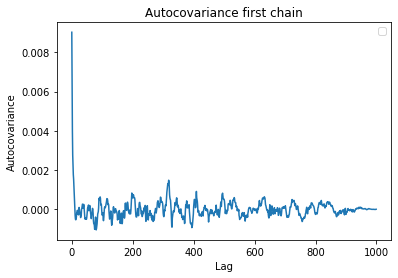

KeyboardInterrupt: 

In [15]:
# Define inputs
mean_prior = np.array([7.])
cov_prior = np.diag([1.])
Yhf = data["Yhf"]
sd_noise = [0.1,0.05]
N = 3000
burn_in = 2000
number_chains = 2
algo = "MH"
x_real = np.array([15.])
proposal_sd = [4.,2.]
adapt = True
n_data = [50,30]


module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure2.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)

x_data=  np.linspace(0., 5., n_data[0]).reshape(-1, 1)  # Generate evaluation times
nearest_x, y_obs = process_data(data["xhf"], x_real, x_data, Yhf) 

# estimates = final_model.inverse_cuqi(
#     mean_prior=mean_prior,
#     x_real=x_real,
#     y_obs=y_obs,
#     N=N,
#     burn_in=burn_in,
#     cov_prior=cov_prior,
#     sd_noise=sd_noise,  
#     adapt=adapt,
#     scale=proposal_sd,
#     proposal_sd=proposal_sd,
#     number_chains=number_chains,
#     algo=algo,
#     x_data=x_data
# )
estimates=run_simulation_cuqi(data,
    mean_prior,
    x_real,
    N,
    burn_in,
    cov_prior,
    sd_noise,  
    adapt,
    
    proposal_sd,
    number_chains,
    algo,
    x_data,
    n_data,
    final_model
) 


In [6]:
import tensorflow as tf
print(tf.__version__)

2.11.0


In [7]:
pip install -U tensorboard_plugin_profile


     ---------------------------------------- 5.7/5.7 MB 22.6 MB/s eta 0:00:00

[notice] A new release of pip available: 22.1.2 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [8]:
!/sbin/ldconfig -N -v $(sed 's/:/ /g' <<< $LD_LIBRARY_PATH) | grep libcupti


<< non atteso.


In [9]:
import os
os.environ['LD_LIBRARY_PATH'] = '/usr/local/cuda/extras/CUPTI/lib64:' + os.environ.get('LD_LIBRARY_PATH', '')


In [10]:
!/sbin/ldconfig -N -v $(sed 's/:/ /g' <<< $LD_LIBRARY_PATH) | grep libcupti


<< non atteso.


In [13]:
import os
import subprocess

def check_cupti():
    try:
        ld_library_path = os.environ.get('LD_LIBRARY_PATH', '')
        paths = ld_library_path.split(':')
        found = False
        for path in paths:
            if os.path.exists(os.path.join(path, 'libcupti.so')):
                print(f'libcupti found in {path}')
                found = True
                break
        if not found:
            print('libcupti not found in any path')
    except Exception as e:
        print(f'Error: {e}')

# Verifica la presenza di CUPTI nel percorso
check_cupti()

# Aggiungi CUPTI alla variabile d'ambiente se necessario
cupti_path = '/usr/local/cuda/extras/CUPTI/lib64'

if 'LD_LIBRARY_PATH' in os.environ:
    if cupti_path not in os.environ['LD_LIBRARY_PATH']:
        os.environ['LD_LIBRARY_PATH'] = cupti_path + ':' + os.environ['LD_LIBRARY_PATH']
else:
    os.environ['LD_LIBRARY_PATH'] = cupti_path

# Verifica nuovamente
check_cupti()

libcupti not found in any path
libcupti not found in any path


In [15]:
!nvcc --version


"nvcc" non � riconosciuto come comando interno o esterno,
 un programma eseguibile o un file batch.


In [ ]:
    @compute_time
    def inverse_cuqi(self, mean_prior: np.ndarray, x_data: np.ndarray, cov_prior: Optional[np.ndarray] = None,
                      cov_noise: float = 0.1, cov_likelihood: Optional[np.ndarray] = None, y_obs: Optional[np.ndarray] = None, 
                      x_real: Optional[np.ndarray] = None, number_chains: int = 1, N: int = 1000, burn_in: int = 500, 
                      levels: int = 1, diagnostic: bool = True, rwmh_cov: Optional[np.ndarray] = None, rwmh_scaling: float = 0.1, 
                      rwmh_adaptive: bool = True, algo: str = "MH", transformation: List[Any] = []) -> Tuple[np.ndarray, np.ndarray]:

        self.transformations = transformation
        self.inputs = x_data

        if x_real is not None:
            dim = x_real.shape[0]
        elif y_obs is not None:
            dim = y_obs.shape[0]
        else:
            warnings.warn("No observation nor data given", UserWarning)
            return np.array([]), np.array([])

        if N <= burn_in:
            warnings.warn("Number of steps insufficient, smaller or equal to burn-in", UserWarning)

        if cov_prior is None:
            cov_prior = np.diag(mean_prior * 0.2)

        if cov_likelihood is None:
            cov_likelihood = cov_noise**2 * np.eye(dim)

        my_prior = multivariate_normal(mean=mean_prior, cov=cov_prior)

        if y_obs is None:
            y_obs = self.wrapper_prediction(x_real) + np.random.normal(loc=0., scale=cov_noise, size=x_real.shape)
        else:
            y_obs += np.random.normal(loc=0., scale=cov_noise, size=y_obs.shape)
            y_obs = y_obs.flatten()

        if levels > 1:
            if levels > len(self.model_list):
                warnings.warn("Number of levels is exceeding the number of models", UserWarning)
            else:
                my_loglike = [Gaussian(mean=y_obs, cov=cov_likelihood) for _ in range(levels)]
                my_posterior = [JointDistribution(my_prior, my_loglike[i])(self.model_list[i].wrapper_prediction) for i in range(levels)]
        else:
            my_loglike = Gaussian(mean=y_obs, cov=cov_likelihood)
            my_posterior = JointDistribution(my_prior, my_loglike)(self.wrapper_prediction)

        if rwmh_cov is None:
            rwmh_cov = np.eye(dim)

        estimates = self.MCMC_cuqi(my_posterior, N, burn_in, number_chains, diagnostic, rwmh_cov, rwmh_scaling, rwmh_adaptive, algo, dim)

        if diagnostic:
            self.plot_hist(estimates, x_real, self.wrapper_prediction(estimates), self.wrapper_prediction(x_real))
        
        error = np.abs(estimates - x_real) / np.abs(x_real + 1e-10)
        return estimates, error

    def MCMC_cuqi(self, posterior, N, burn_in, n=1, diagnostic=True, rwmh_cov=None, rwmh_scaling=0.1, rwmh_adaptive=True, algo="MH", dim=1):
        
        x_init = np.random.rand(dim, n)
        estimates = np.empty((dim, 0))
        chains = np.empty((0, dim, N - burn_in))
        post = np.empty((dim, 0))

        for i in range(n):
            if algo == "NUTS":
                sampler = NUTS(posterior, x0=x_init[:, i])
            elif algo == "MH":
                if rwmh_adaptive:
                    sampler = MH(posterior, x0=x_init[:, i], scale=rwmh_scaling)
                else:
                    sampler = MH(posterior, x0=x_init[:, i], scale=rwmh_scaling)
            elif algo == "pCN":
                sampler = pCN(posterior, x0=x_init[:, i])
            else:
                raise ValueError("Unknown algorithm %s" % algo)
            
            if rwmh_adaptive:
                samples = sampler.sample_adapt(N - burn_in, burn_in)
            else:
                samples = sampler.sample(N - burn_in, burn_in)

            estimates = np.column_stack((estimates, samples.mean()[:, np.newaxis]))
            chains = np.concatenate((chains, np.expand_dims(samples.samples, axis=0)), axis=0)
            post = np.concatenate((post, samples.samples), axis=1)

            print(f"Mean values = {estimates.mean(axis=1)}")

        print(chains.shape)
        for l in range(chains.shape[1]):
            plt.figure(figsize=(10, 4))
            for i in range(chains.shape[0]):
                plt.plot(chains[i, l, :])
            plt.xlabel('Sample')
            plt.ylabel('Value')
            plt.title(f'Trace Plot variable {l}')
            plt.legend()
            plt.show()
        
        if diagnostic:
            if n == 1:
                samples.plot_trace()
                samples.plot_autocorrelation()
            else:
                num_bins = 20
                plt.figure()
                for num in range(post.shape[0]):        
                    bin_edges = np.linspace(np.min(post[num, :]), np.max(post[num, :]), num_bins + 1)
                    hist, _ = np.histogram(post[num, :], bins=bin_edges)
                    hist = hist / post.shape[1]
                    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
                    plt.bar(bin_centers, hist, width=np.diff(bin_edges), edgecolor='black', label=f'Var {num + 1}')
                    plt.xlabel('Value')
                    plt.ylabel('Probability')
                    plt.title('Distribution')
                    plt.legend()
                    plt.show()
                
                autocov = arviz.autocov(chains[:, 0, :])
                ess = arviz.ess(chains[:, 0, :])
                print(f"ESS values = {ess}")
                plt.figure()
                plt.plot(autocov[0, :])
                plt.title('Autocovariance first chain')
                plt.xlabel('Lag')
                plt.ylabel('Autocovariance')
                plt.legend()
                plt.show()
        
        return estimates